In [1]:

# Basic Libraries
import numpy as np
import pandas as pd
import os
import re
import random
import matplotlib.pyplot as plt
import seaborn as sns

# Text Preprocessing
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download('punkt')
nltk.download('stopwords')

# Deep Learning
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Bidirectional, Dense, Dropout, Attention, Concatenate, GlobalAveragePooling1D
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\hP\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hP\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


# Load Dataset (Combine Multiple CSV Files)

In [3]:
import pandas as pd, os

data_dir = "archive"
files = [f for f in os.listdir(data_dir) if f.endswith('.csv')]

print("Total CSVs found:", len(files))
print("First few files:", files[:5])

# Check one file's columns
sample = pd.read_csv(os.path.join(data_dir, files[0]))
print("\nColumns in first file:", sample.columns.tolist())
print(sample.head())


Total CSVs found: 395
First few files: ['absence-of-certain-changes-or-events.csv', 'absence-of-certain-changes.csv', 'acceleration.csv', 'access-to-information.csv', 'access.csv']

Columns in first file: ['clause_text', 'clause_type']
                                         clause_text  \
0  Absence of Certain Changes or Events. Except a...   
1  Absence of Certain Changes or Events. Since Ma...   
2  Absence of Certain Changes or Events. (a) Sinc...   
3  Absence of Certain Changes or Events. Since th...   
4  Absence of Certain Changes or Events. Except a...   

                            clause_type  
0  absence-of-certain-changes-or-events  
1  absence-of-certain-changes-or-events  
2  absence-of-certain-changes-or-events  
3  absence-of-certain-changes-or-events  
4  absence-of-certain-changes-or-events  


In [4]:
import os
import pandas as pd

data_dir = "archive"
files = [f for f in os.listdir(data_dir) if f.endswith('.csv')]

all_clauses = []

for file in files:
    df = pd.read_csv(os.path.join(data_dir, file))
    
    # Normalize column names
    df.columns = [c.strip().lower() for c in df.columns]
    
    # Check if expected columns exist
    if "clause_text" in df.columns and "clause_type" in df.columns:
        df = df[["clause_text", "clause_type"]]
        df.rename(columns={"clause_text": "clause"}, inplace=True)
        all_clauses.append(df)

# Combine everything
if len(all_clauses) > 0:
    data = pd.concat(all_clauses, ignore_index=True)
    print(f"✅ Total clauses loaded: {len(data)}")
    display(data.head())
else:
    print("⚠️ No valid CSVs found.")



✅ Total clauses loaded: 150881


,clause,clause_type
0,Absence of Certain Changes or Events. Except a...,absence-of-certain-changes-or-events
1,Absence of Certain Changes or Events. Since Ma...,absence-of-certain-changes-or-events
2,Absence of Certain Changes or Events. (a) Sinc...,absence-of-certain-changes-or-events
3,Absence of Certain Changes or Events. Since th...,absence-of-certain-changes-or-events
4,Absence of Certain Changes or Events. Except a...,absence-of-certain-changes-or-events


In [5]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)   # keep only letters and spaces
    words = word_tokenize(text)
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

data['clean_clause'] = data['clause'].apply(clean_text)
print("✅ Text cleaning complete!")
data.head()



[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\hP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


✅ Text cleaning complete!


,clause,clause_type,clean_clause
0,Absence of Certain Changes or Events. Except a...,absence-of-certain-changes-or-events,absence certain changes events except set fort...
1,Absence of Certain Changes or Events. Since Ma...,absence-of-certain-changes-or-events,absence certain changes events since march exc...
2,Absence of Certain Changes or Events. (a) Sinc...,absence-of-certain-changes-or-events,absence certain changes events since december ...
3,Absence of Certain Changes or Events. Since th...,absence-of-certain-changes-or-events,absence certain changes events since date comp...
4,Absence of Certain Changes or Events. Except a...,absence-of-certain-changes-or-events,absence certain changes events except set fort...


In [6]:


import random
import numpy as np

def create_pairs(df, num_pairs=20000):
    pairs = []
    labels = []
    clause_types = df['clause_type'].unique()

    for _ in range(num_pairs):
        if random.random() > 0.5:
            # Positive pair (same type)
            ctype = random.choice(clause_types)
            same = df[df['clause_type'] == ctype]
            if len(same) >= 2:
                a, b = same.sample(2)['clean_clause'].values
                pairs.append((a, b))
                labels.append(1)
        else:
            # Negative pair (different types)
            a = df.sample(1)['clean_clause'].values[0]
            b = df.sample(1)['clean_clause'].values[0]
            pairs.append((a, b))
            labels.append(0)

    return pd.DataFrame(pairs, columns=['clause1', 'clause2']), np.array(labels)

pairs_df, labels = create_pairs(data)
print("✅ Pairs created:", len(pairs_df))
pairs_df.head()


✅ Pairs created: 20000


,clause1,clause2
0,integration date agreement neither company aff...,integration except may otherwise provided here...
1,preamble annex b prepared accordance simplifie...,bank accounts attached hereto schedule list ba...
2,general intent parties payments benefits agree...,general responsible company respect material t...
3,applicable law agreement shall governed constr...,investments borrower make permit subsidiaries ...
4,waivers waiver party whether express implied r...,waivers servicer owner may upon consent partie...


In [7]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

MAX_LEN = 50       # Maximum number of words per clause
VOCAB_SIZE = 10000 # Maximum vocabulary size

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(list(pairs_df['clause1']) + list(pairs_df['clause2']))

# Convert text to integer sequences
seq1 = tokenizer.texts_to_sequences(pairs_df['clause1'])
seq2 = tokenizer.texts_to_sequences(pairs_df['clause2'])

# Pad sequences so they all have same length
X1 = pad_sequences(seq1, maxlen=MAX_LEN, padding='post', truncating='post')
X2 = pad_sequences(seq2, maxlen=MAX_LEN, padding='post', truncating='post')

# Split data into train/test
X1_train, X1_test, X2_train, X2_test, y_train, y_test = train_test_split(
    X1, X2, labels, test_size=0.2, random_state=42
)

print(f"✅ Tokenization complete! Train size: {len(X1_train)}, Test size: {len(X1_test)}")


✅ Tokenization complete! Train size: 16000, Test size: 4000


## BiLSTM Model

In [8]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Bidirectional, Dense, Concatenate, Dropout
from tensorflow.keras.optimizers import Adam

def build_bilstm_model(vocab_size=10000, embed_dim=128, lstm_units=64, max_len=50):
    # Define inputs
    input1 = Input(shape=(max_len,))
    input2 = Input(shape=(max_len,))
    
    # Shared embedding + BiLSTM encoder
    embedding = Embedding(vocab_size, embed_dim, input_length=max_len)
    bilstm = Bidirectional(LSTM(lstm_units))
    
    encoded1 = bilstm(embedding(input1))
    encoded2 = bilstm(embedding(input2))
    
    # Combine both encoded clause representations
    merged = Concatenate()([encoded1, encoded2])
    merged = Dense(128, activation='relu')(merged)
    merged = Dropout(0.3)(merged)
    output = Dense(1, activation='sigmoid')(merged)
    
    model = Model(inputs=[input1, input2], outputs=output)
    model.compile(optimizer=Adam(learning_rate=1e-3),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    
    return model

bilstm_model = build_bilstm_model(vocab_size=VOCAB_SIZE, max_len=MAX_LEN)
bilstm_model.summary()


c:\Users\hP\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 50, 128)   │  1,280,000 │ input_layer[0][0… │
│ (Embedding)         │                   │            │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 128)       │     98,816 │ embedding[0][0],  │
│ (Bidirectional)     │                   │            │ embedding[1][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256)       │          0 │ bidirectional[0]… │
│ (Concatenate)       │                   │            │ bidirectional[1]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     32,896 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │        129 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,411,841 (5.39 MB)

 Trainable params: 1,411,841 (5.39 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history_bilstm = bilstm_model.fit(
    [X1_train, X2_train], y_train,
    validation_data=([X1_test, X2_test], y_test),
    epochs=5,
    batch_size=64,
    verbose=1
)


Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 25s 75ms/step - accuracy: 0.6794 - loss: 0.5478 - val_accuracy: 0.9200 - val_loss: 0.2306
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 18s 67ms/step - accuracy: 0.9442 - loss: 0.1703 - val_accuracy: 0.9557 - val_loss: 0.1655
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 17s 68ms/step - accuracy: 0.9579 - loss: 0.1342 - val_accuracy: 0.9635 - val_loss: 0.1344
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 17s 69ms/step - accuracy: 0.9667 - loss: 0.1106 - val_accuracy: 0.9617 - val_loss: 0.1308
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 19s 75ms/step - accuracy: 0.9734 - loss: 0.0916 - val_accuracy: 0.9567 - val_loss: 0.1371


In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np

# Predict
y_pred_bilstm = (bilstm_model.predict([X1_test, X2_test]) > 0.5).astype(int)

# Metrics
acc = accuracy_score(y_test, y_pred_bilstm)
prec = precision_score(y_test, y_pred_bilstm)
rec = recall_score(y_test, y_pred_bilstm)
f1 = f1_score(y_test, y_pred_bilstm)
roc = roc_auc_score(y_test, y_pred_bilstm)

print(f"📈 BiLSTM Performance:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC-AUC: {roc:.4f}")


125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step
📈 BiLSTM Performance:
Accuracy: 0.9567
Precision: 0.9281
Recall: 0.9894
F1 Score: 0.9578
ROC-AUC: 0.9570


# Attention-Based Model


In [11]:
from tensorflow.keras.layers import Attention, GlobalAveragePooling1D

def build_attention_model(vocab_size=10000, embed_dim=128, max_len=50):
    input1 = Input(shape=(max_len,))
    input2 = Input(shape=(max_len,))
    
    embedding = Embedding(vocab_size, embed_dim, input_length=max_len)
    
    x1 = embedding(input1)
    x2 = embedding(input2)
    
    # Attention layer: compares both sequences
    attention = Attention()([x1, x2])
    x = GlobalAveragePooling1D()(attention)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    output = Dense(1, activation='sigmoid')(x)
    
    model = Model(inputs=[input1, input2], outputs=output)
    model.compile(optimizer=Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
    return model

attn_model = build_attention_model(vocab_size=VOCAB_SIZE, max_len=MAX_LEN)
attn_model.summary()


c:\Users\hP\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 50, 128)   │  1,280,000 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 50, 128)   │          0 │ embedding_1[0][0… │
│ (Attention)         │                   │            │ embedding_1[1][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ attention[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     16,512 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │        129 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,296,641 (4.95 MB)

 Trainable params: 1,296,641 (4.95 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
history_attn = attn_model.fit(
    [X1_train, X2_train], y_train,
    validation_data=([X1_test, X2_test], y_test),
    epochs=5,
    batch_size=64,
    verbose=1
)


Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.5114 - loss: 0.6928 - val_accuracy: 0.4972 - val_loss: 0.6930
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.5489 - loss: 0.6827 - val_accuracy: 0.5345 - val_loss: 0.6931
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.6022 - loss: 0.6488 - val_accuracy: 0.5355 - val_loss: 0.7088
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.6441 - loss: 0.6035 - val_accuracy: 0.5477 - val_loss: 0.7448
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.6804 - loss: 0.5547 - val_accuracy: 0.5397 - val_loss: 0.7934


In [13]:
# Predict
y_pred_attn = (attn_model.predict([X1_test, X2_test]) > 0.5).astype(int)

# Metrics
acc2 = accuracy_score(y_test, y_pred_attn)
prec2 = precision_score(y_test, y_pred_attn)
rec2 = recall_score(y_test, y_pred_attn)
f12 = f1_score(y_test, y_pred_attn)
roc2 = roc_auc_score(y_test, y_pred_attn)

print(f"📈 Attention Model Performance:")
print(f"Accuracy: {acc2:.4f}")
print(f"Precision: {prec2:.4f}")
print(f"Recall: {rec2:.4f}")
print(f"F1 Score: {f12:.4f}")
print(f"ROC-AUC: {roc2:.4f}")


125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
📈 Attention Model Performance:
Accuracy: 0.5397
Precision: 0.5310
Recall: 0.6127
F1 Score: 0.5690
ROC-AUC: 0.5404


In [14]:
def build_attention_lstm_model(vocab_size=10000, embed_dim=128, lstm_units=64, max_len=50):
    input1 = Input(shape=(max_len,))
    input2 = Input(shape=(max_len,))
    
    embedding = Embedding(vocab_size, embed_dim, input_length=max_len)
    lstm = Bidirectional(LSTM(lstm_units, return_sequences=True))
    
    x1 = lstm(embedding(input1))
    x2 = lstm(embedding(input2))
    
    attention = Attention()([x1, x2])
    x = GlobalAveragePooling1D()(attention)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    output = Dense(1, activation='sigmoid')(x)
    
    model = Model(inputs=[input1, input2], outputs=output)
    model.compile(optimizer=Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
    return model


In [15]:
attn_lstm_model = build_attention_lstm_model(vocab_size=VOCAB_SIZE, max_len=MAX_LEN)
attn_lstm_model.summary()

history_attn_lstm = attn_lstm_model.fit(
    [X1_train, X2_train], y_train,
    validation_data=([X1_test, X2_test], y_test),
    epochs=5,
    batch_size=64,
    verbose=1
)


c:\Users\hP\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_5       │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 50, 128)   │  1,280,000 │ input_layer_4[0]… │
│ (Embedding)         │                   │            │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 50, 128)   │     98,816 │ embedding_2[0][0… │
│ (Bidirectional)     │                   │            │ embedding_2[1][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_1         │ (None, 50, 128)   │          0 │ bidirectional_1[… │
│ (Attention)         │                   │            │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ attention_1[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │     16,512 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │        129 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,395,457 (5.32 MB)

 Trainable params: 1,395,457 (5.32 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 41s 117ms/step - accuracy: 0.5036 - loss: 0.6936 - val_accuracy: 0.5167 - val_loss: 0.6921
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 31s 78ms/step - accuracy: 0.5479 - loss: 0.6831 - val_accuracy: 0.5502 - val_loss: 0.6894
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 20s 76ms/step - accuracy: 0.6061 - loss: 0.6484 - val_accuracy: 0.5720 - val_loss: 0.6913
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 21s 76ms/step - accuracy: 0.6559 - loss: 0.5958 - val_accuracy: 0.5880 - val_loss: 0.6865
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 19s 75ms/step - accuracy: 0.7069 - loss: 0.5291 - val_accuracy: 0.6060 - val_loss: 0.7078


In [16]:
y_pred_attn_lstm = (attn_lstm_model.predict([X1_test, X2_test]) > 0.5).astype(int)

acc3 = accuracy_score(y_test, y_pred_attn_lstm)
prec3 = precision_score(y_test, y_pred_attn_lstm)
rec3 = recall_score(y_test, y_pred_attn_lstm)
f13 = f1_score(y_test, y_pred_attn_lstm)
roc3 = roc_auc_score(y_test, y_pred_attn_lstm)

print(f"📈 BiLSTM + Attention Model Performance:")
print(f"Accuracy: {acc3:.4f}")
print(f"Precision: {prec3:.4f}")
print(f"Recall: {rec3:.4f}")
print(f"F1 Score: {f13:.4f}")
print(f"ROC-AUC: {roc3:.4f}")


125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step
📈 BiLSTM + Attention Model Performance:
Accuracy: 0.6060
Precision: 0.6029
Recall: 0.6011
F1 Score: 0.6020
ROC-AUC: 0.6060


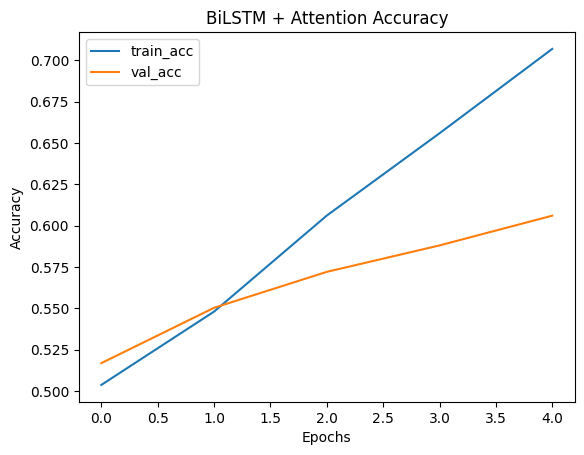

In [17]:
plt.plot(history_attn_lstm.history['accuracy'], label='train_acc')
plt.plot(history_attn_lstm.history['val_accuracy'], label='val_acc')
plt.title('BiLSTM + Attention Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
